# Exploring a real Sentinel-2 scene

Before writing the distributed tiling logic, let's look at the real scene downloaded by `data/pull_sentinel_scene.py`: its size, value ranges, a visual composite, and a preview of how it will be split into tiles.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import Window

SCENE_DIR = Path("../data/sentinel2_scene")
BANDS = {"red": "B04.jp2", "green": "B03.jp2", "blue": "B02.jp2"}
TILE_SIZE = 64  # matches the EuroSAT tile size the classifier was trained on

## Scene size and expected tile count

In [2]:
with rasterio.open(SCENE_DIR / BANDS["red"]) as src:
    full_width, full_height = src.width, src.height
    crs = src.crs
    dtype = src.dtypes[0]

n_tiles = (full_width // TILE_SIZE) * (full_height // TILE_SIZE)

print(f"Scene size: {full_width} x {full_height} pixels")
print(f"CRS: {crs}")
print(f"Dtype: {dtype}")
print(f"Tiles of {TILE_SIZE}x{TILE_SIZE}px: {n_tiles}")

Scene size: 10980 x 10980 pixels
CRS: EPSG:32631
Dtype: uint16
Tiles of 64x64px: 29241


## Full-scene RGB composite

The full scene is far too large to render directly (10980x10980 per band) — read a downsampled version for this preview only. The actual tiling logic will operate on the full-resolution data.

In [3]:
DISPLAY_SIZE = 1024


def read_band_downsampled(path, size):
    with rasterio.open(path) as src:
        return src.read(1, out_shape=(size, size), resampling=Resampling.average)


def stretch(band, low=2, high=98):
    """Percentile contrast stretch — L1C reflectance values are raw 16-bit,
    so most pixels sit in a narrow low range without this."""
    lo, hi = np.percentile(band, [low, high])
    return np.clip((band.astype(np.float32) - lo) / (hi - lo), 0, 1)


preview_rgb = np.stack(
    [read_band_downsampled(SCENE_DIR / BANDS[c], DISPLAY_SIZE) for c in ("red", "green", "blue")],
    axis=-1,
)

print(f"Preview array shape: {preview_rgb.shape}, dtype: {preview_rgb.dtype}")
for i, c in enumerate(("red", "green", "blue")):
    print(f"{c}: min={preview_rgb[..., i].min()}, max={preview_rgb[..., i].max()}")

Preview array shape: (1024, 1024, 3), dtype: uint16
red: min=1100, max=8616
green: min=1479, max=7604
blue: min=1609, max=7070


/tmp/ipykernel_3114/1632708420.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  return src.read(1, out_shape=(size, size), resampling=Resampling.average)


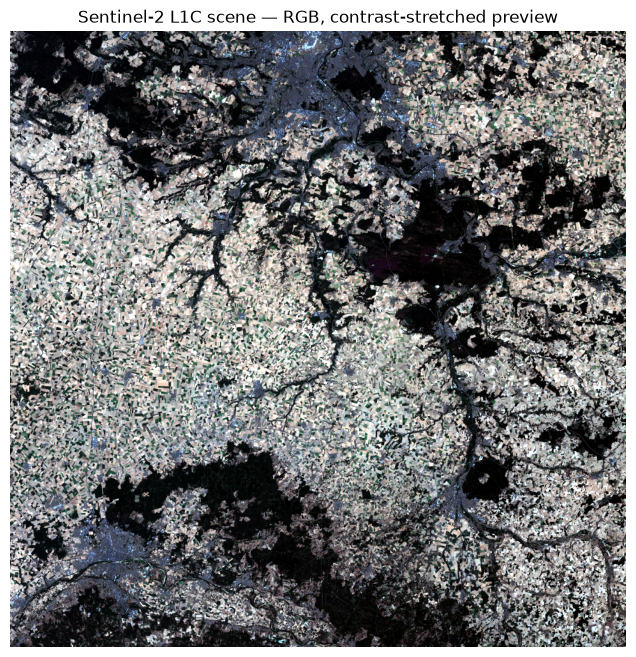

In [4]:
preview_stretched = np.stack([stretch(preview_rgb[..., i]) for i in range(3)], axis=-1)

plt.figure(figsize=(8, 8))
plt.imshow(preview_stretched)
plt.title("Sentinel-2 L1C scene — RGB, contrast-stretched preview")
plt.axis("off")
plt.show()

## Tile grid preview

Overlaying a 64x64 grid on the full downsampled scene would just look like a solid mesh (~171x171 tiles across the whole image) — instead, crop a small full-resolution window near the scene's center and show the actual tile boundaries on it, before writing the real tiling logic.

/tmp/ipykernel_3114/2755718007.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  return src.read(1, window=window)


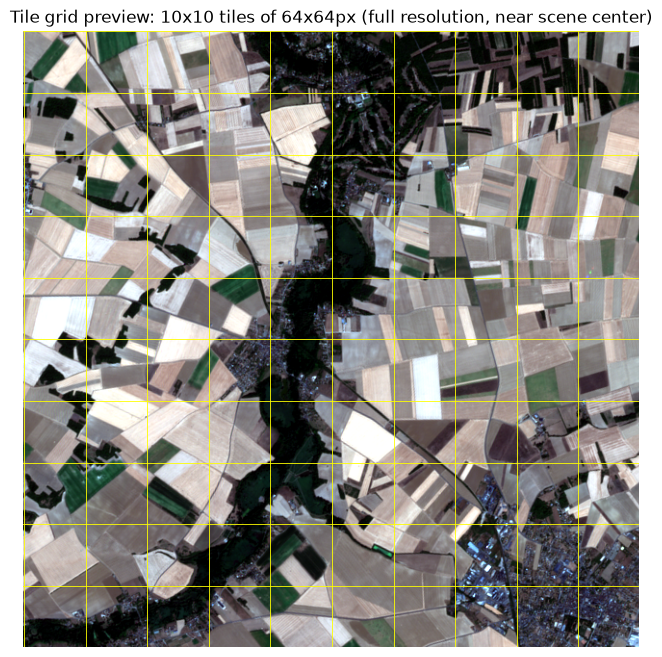

In [5]:
CROP_TILES = 10  # show a 10x10 grid of tiles
crop_size = TILE_SIZE * CROP_TILES

crop_window = Window(full_width // 2, full_height // 2, crop_size, crop_size)


def read_band_window(path, window):
    with rasterio.open(path) as src:
        return src.read(1, window=window)


crop_rgb = np.stack(
    [read_band_window(SCENE_DIR / BANDS[c], crop_window) for c in ("red", "green", "blue")],
    axis=-1,
)
crop_stretched = np.stack([stretch(crop_rgb[..., i]) for i in range(3)], axis=-1)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(crop_stretched)
for x in range(0, crop_size, TILE_SIZE):
    ax.axvline(x, color="yellow", linewidth=0.6)
for y in range(0, crop_size, TILE_SIZE):
    ax.axhline(y, color="yellow", linewidth=0.6)
ax.set_title(f"Tile grid preview: {CROP_TILES}x{CROP_TILES} tiles of {TILE_SIZE}x{TILE_SIZE}px (full resolution, near scene center)")
ax.axis("off")
plt.show()

## Classifying the tile grid with the trained model

A preview of what Phase 4 (distributed inference) will do: run each tile of the crop above through the ResNet18 trained on EuroSAT, and color it by predicted class.

Caveat: Sentinel-2 L1C tiles are raw 16-bit reflectance, while the model was trained on EuroSAT's already-rendered 8-bit RGB images. Each tile is rescaled with the same per-tile percentile stretch used for display, as an approximation of that rendering — not a proper radiometric calibration. Treat these predictions as illustrative, not a real accuracy measurement; getting this conversion right is Phase 4's job.

In [6]:
import json

import torch
from torch import nn
from torchvision.datasets import EuroSAT
from torchvision.models import ResNet18_Weights, resnet18

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

classes = EuroSAT(root="../data", download=False).classes
num_classes = len(classes)

with open("../data/eurosat_stats.json") as f:
    stats = json.load(f)
EUROSAT_MEAN = torch.tensor(stats["mean"]).view(3, 1, 1)
EUROSAT_STD = torch.tensor(stats["std"]).view(3, 1, 1)

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load("../models/resnet18_eurosat_best.pt", map_location=device))
model = model.to(device).eval()

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth



  0%|          | 0.00/44.7M [00:00<?, ?B/s]


 24%|██▍       | 10.9M/44.7M [00:00<00:00, 114MB/s]


 50%|████▉     | 22.1M/44.7M [00:00<00:00, 116MB/s]


 75%|███████▌  | 33.5M/44.7M [00:00<00:00, 117MB/s]


100%|██████████| 44.7M/44.7M [00:00<00:00, 116MB/s]

In [7]:
predictions = np.empty((CROP_TILES, CROP_TILES), dtype=int)

with torch.no_grad():
    for row in range(CROP_TILES):
        for col in range(CROP_TILES):
            tile = crop_rgb[
                row * TILE_SIZE : (row + 1) * TILE_SIZE,
                col * TILE_SIZE : (col + 1) * TILE_SIZE,
                :,
            ]
            tile_stretched = np.stack([stretch(tile[..., i]) for i in range(3)], axis=-1)

            tensor = torch.from_numpy(tile_stretched.transpose(2, 0, 1)).float()
            tensor = (tensor - EUROSAT_MEAN) / EUROSAT_STD
            tensor = tensor.unsqueeze(0).to(device)

            output = model(tensor)
            predictions[row, col] = output.argmax(dim=1).item()

print("Predicted class counts:")
for c in range(num_classes):
    count = (predictions == c).sum()
    if count > 0:
        print(f"  {classes[c]:25s} {count}")

Predicted class counts:
  AnnualCrop                15
  HerbaceousVegetation      17
  Highway                   2
  Industrial                61
  River                     2
  SeaLake                   3


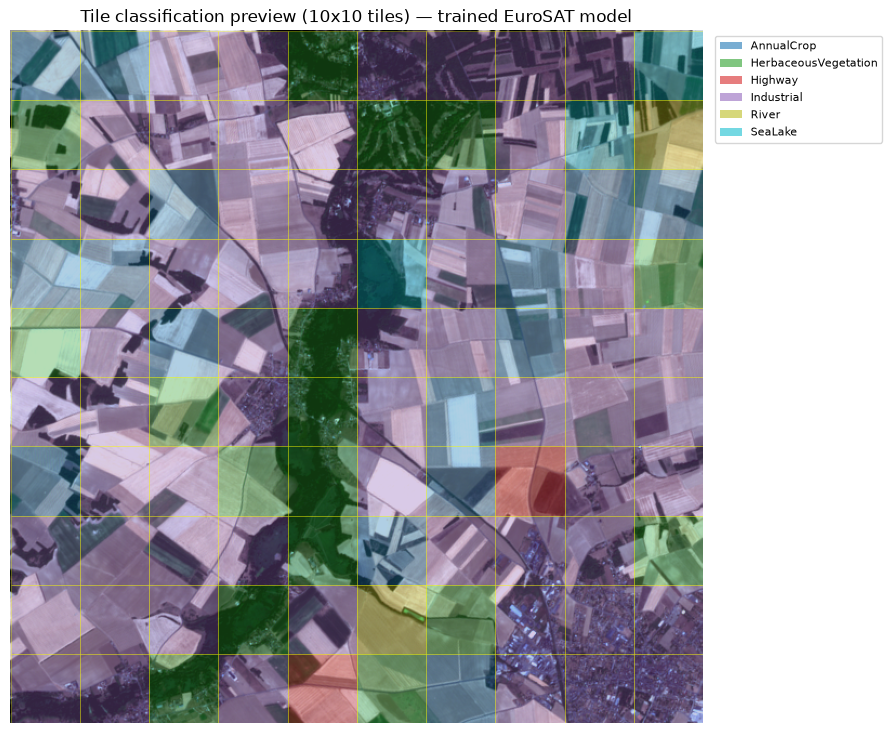

In [8]:
CLASS_COLORS = plt.cm.tab10(np.linspace(0, 1, num_classes))

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(crop_stretched)

for row in range(CROP_TILES):
    for col in range(CROP_TILES):
        color = CLASS_COLORS[predictions[row, col]]
        rect = plt.Rectangle(
            (col * TILE_SIZE, row * TILE_SIZE), TILE_SIZE, TILE_SIZE,
            linewidth=0.6, edgecolor="yellow", facecolor=color, alpha=0.35,
        )
        ax.add_patch(rect)

present_classes = sorted(set(predictions.flatten()))
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=CLASS_COLORS[c], alpha=0.6, label=classes[c])
    for c in present_classes
]
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
ax.set_title(f"Tile classification preview ({CROP_TILES}x{CROP_TILES} tiles) — trained EuroSAT model")
ax.axis("off")
plt.tight_layout()
plt.show()